# 01 – Explorative Datenanalyse (EDA)

Inhalt des Notebooks
- Deskriptive Analyse des Datensatzes
- Analyse der Preisverteilung

In [1]:
# Imports und Daten laden

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/sample_listings.csv")
print (f"Datensatz mit {df.shape[0]} Zeilen und {df.shape[1]} Spalten geladen.")

Datensatz mit 5000 Zeilen und 9 Spalten geladen.


In [2]:
# Daten anzeigen

df.head()

,price,neighbourhood,room_type,minimum_nights,number_of_reviews,review_scores_rating,amenities,latitude,longitude
0,205.0,I Centro Storico,Entire home/apt,1,59,4.68,"[""Hangers"", ""Pack \u2019n play/Travel crib"", ""...",41.877946,12.473666
1,149.0,VIII Appia Antica,Entire home/apt,3,13,5.00,"[""Hangers"", ""Carbon monoxide alarm"", ""Clothing...",41.860463,12.483244
2,67.0,XIII Aurelia,Entire home/apt,1,94,4.95,"[""Heating"", ""Free parking on premises"", ""Clean...",41.894668,12.447176
3,102.0,I Centro Storico,Private room,5,435,4.80,"[""Air conditioning"", ""Hangers"", ""Wifi"", ""Host ...",41.894140,12.506500
4,140.0,I Centro Storico,Entire home/apt,2,54,4.76,"[""Hangers"", ""Pack \u2019n play/Travel crib"", ""...",41.912990,12.455640


In [3]:
# Deskriptive Statistik

df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
price,5000.0,NaN,NaN,NaN,152.2294,82.883699,23.0,94.0,130.0,184.0,500.0
neighbourhood,5000,15,I Centro Storico,2453,NaN,NaN,NaN,NaN,NaN,NaN,NaN
room_type,5000,4,Entire home/apt,3871,NaN,NaN,NaN,NaN,NaN,NaN,NaN
minimum_nights,5000.0,NaN,NaN,NaN,1.8696,1.231787,1.0,1.0,2.0,2.0,30.0
number_of_reviews,5000.0,NaN,NaN,NaN,64.8528,103.670292,0.0,4.0,24.0,78.0,1167.0
review_scores_rating,5000.0,NaN,NaN,NaN,4.796756,0.268261,1.0,4.74,4.86,4.96,5.0
amenities,5000,4932,"[""Air conditioning"", ""Wifi"", ""First aid kit"", ...",5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,5000.0,NaN,NaN,NaN,41.892106,0.034336,41.71795,41.883678,41.896369,41.90656,42.12007
longitude,5000.0,NaN,NaN,NaN,12.479277,0.048671,12.25835,12.457465,12.476599,12.505363,12.709461


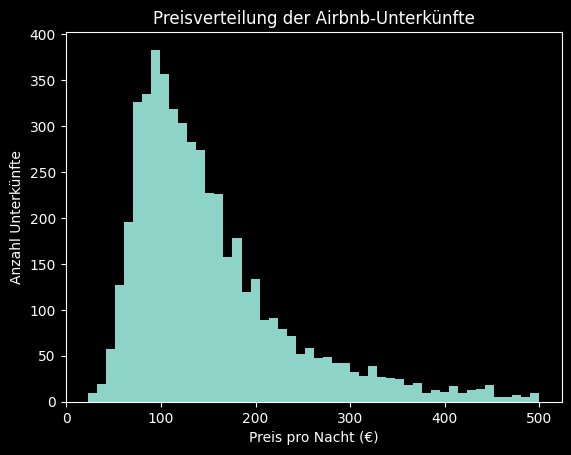

In [4]:
# Preisverteilung visualisieren

plt.hist(df["price"], bins=50)
plt.xlabel("Preis pro Nacht (€)")
plt.ylabel("Anzahl Unterkünfte")
plt.title("Preisverteilung der Airbnb-Unterkünfte")
plt.show()


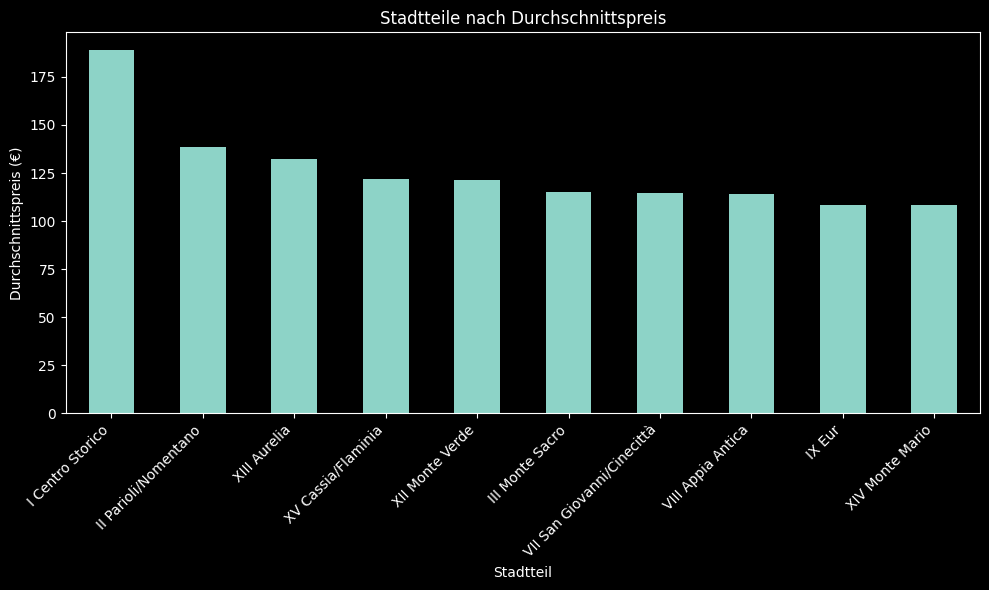

In [5]:
# Teuersten Stadtteile nach Durchschnittspreis

top_neigh = (
    df.groupby("neighbourhood")["price"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(10, 6))

top_neigh.plot(kind="bar", ax=ax)

ax.set_ylabel("Durchschnittspreis (€)")
ax.set_xlabel("Stadtteil")
ax.set_title("Stadtteile nach Durchschnittspreis")

plt.xticks(rotation=45, ha="right")
fig.tight_layout()

plt.show()



## Fazit

- Informationen zum Datensatz
    - 3.000 Zeilen (relativ klein)
    - 9 Spalten
        - 1 Zielvariable (`price`)
        - 2 kategorische Features (`amenities` und `neighbourhood`)
        - 7 numerische Features
- Erkenntnisse zur Preisverteilung 
    - Durchschnittlicher Preis liegt bei ca. 150 €, Medianpreis liegt bei ca. 130 €
    - Teuersten Unterkünfte befinden sich im Stadtzentrum (Centro Storico)
    - Rechtsschiefe Verteilung der Preise
